In [1]:
import os
# import shutil
import warnings
import sys
# import glob
import re
from datetime import date, datetime, timedelta
# from dateutil.relativedelta import relativedelta
from collections import defaultdict
from collections import OrderedDict
from scipy import stats
# import scipy.io
import csv
import xlsxwriter
from statistics import mode
import math
import time
from tqdm.notebook import tqdm_notebook
import numpy as np
import pandas as pd
# import seaborn as sns
import openpyxl as xl
from copy import copy
# from copy import deepcopy
%matplotlib widget
import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
# import statsmodels.api as sm
# from bioinfokit.analys import stat
# from statsmodels.formula.api import ols
# import pingouin as pg
# from statsmodels.graphics.factorplots import interaction_plot
# from brokenaxes import brokenaxes
# import matplotlib.patheffects as pe
from matplotlib import container
# import concurrent.futures
# from itertools import starmap
# import multiprocessing as mp
# from brokenaxes import brokenaxes
from pptx import Presentation
from pptx.util import Inches, Pt
import tkinter as tk
import tkinter.filedialog as fd

In [2]:
# hide these warnings
warnings.filterwarnings(action='ignore', message='.*converting a masked element to nan.*')

# Some plotting presets
# plt.rc("errorbar", capsize=3)
plt.rc("figure", dpi=70)
plt.rc("savefig", dpi=40, facecolor="white", bbox="tight")

In [3]:
#print python version
python_version = sys.version
print(python_version)

## Choose analysis files
initial_dir = "C:\\"
print("Please select the files to analyze:")

time.sleep(0.25)
root = tk.Tk()
root.filenames = fd.askopenfilenames(initialdir=initial_dir,
                                     title="Please select the files to analyze",
                                     filetypes=(("csv files", "*.csv"), ("all files", "*.*")))
input_files = [os.path.basename(f) for f in root.filenames]
input_dir = os.path.dirname(root.filenames[0])
root.destroy()

print("Please choose the output folder:")
time.sleep(0.25)

root = tk.Tk()
root.filenames = fd.askdirectory(initialdir=input_dir,
                                 title="Please select the output folder")
output_dir = root.filenames
root.destroy()

os.chdir(input_dir)
print('Working directory is:', input_dir, '\n')
print('Output folder is:', output_dir,'\n')

3.10.0 | packaged by conda-forge | (default, Nov 10 2021, 13:20:59) [MSC v.1916 64 bit (AMD64)]
Please select the files to analyze:
Please choose the output folder:
Working directory is: C:/Users/pc/Desktop/Reem2-20220207T121758Z-001/Reem2 

Output folder is: C:/Users/pc/Desktop/Reem2-20220207T121758Z-001/Reem2 



In [4]:
# Couple each file with its date of creation
messydatesdict = OrderedDict()
for fl in input_files:
    if '_spike_' not in fl:
        with open(fl, encoding='UTF-8') as csv_file:
            csv_reader = csv.reader(csv_file, delimiter=',')
            row = list(csv_reader)
            for lin in row[75:76]:
                if any('Analysis Duration (s):' in e.strip() for e in lin):
                    duration = round(float(lin[1])/2)
            for lin in row[5:7]:
                if any('Original File Time' in e.strip() for e in lin):
                    stamp = lin[1].split(' ')[0]
                    clock = lin[1].split(' ')[1]
                    year = int(stamp.split('/')[2])
                    month = int(stamp.split('/')[0])
                    day = int(stamp.split('/')[1])
                    hour = int(clock.split(':')[0])
                    minute = int(clock.split(':')[1])
                    second = int(clock.split(':')[2])
                    messydatesdict[fl] = datetime(year,month,day,hour,minute,second) + timedelta(seconds=duration)

# Sort file names by their date of creation
messydatesdict = dict(sorted(messydatesdict.items(), key=lambda x: datetime.strptime(str(x[1]), '%Y-%m-%d %H:%M:%S')))
for k, v in messydatesdict.items():
    print(k, v)

div1(000)(000).csv 2022-01-19 15:59:17
div2(000)(000).csv 2022-01-20 18:15:50
div3(000)(000).csv 2022-01-21 18:04:22
div4(000)(000).csv 2022-01-22 17:21:06
div5(000)(000).csv 2022-01-23 18:07:56
div7(000)(000).csv 2022-01-25 15:48:14
bl div8(000)(000).csv 2022-01-26 09:45:31
ac 38 degrees div8(000)(000).csv 2022-01-26 10:13:35
39 degrees div8(000)(000).csv 2022-01-26 10:34:30
40 degrees div8(000)(000).csv 2022-01-26 10:59:58
div9(000)(000).csv 2022-01-27 13:15:52
div10(000)(000).csv 2022-01-28 11:05:35
div11(000)(000).csv 2022-01-29 11:37:28
div12(000)(000).csv 2022-01-30 13:35:30


In [5]:
# "clean" file names
cleandatesdict = OrderedDict()
datesforaveragemerging = OrderedDict()
for key, value in messydatesdict.items():
    new_key = key.split('.')[0].replace('(000)(000)', '').replace('(000)', '').replace('(00', ' ').replace('(0', ' ').replace(')', '')
    cleandatesdict[new_key] = str(value)
    datesforaveragemerging[new_key] = value
acutedatesdict = {}
for k, v in cleandatesdict.items():
    if 'bl' in k or 'ac' in k:
        acutedatesdict[k] = v 
    print(k, v)

div1 2022-01-19 15:59:17
div2 2022-01-20 18:15:50
div3 2022-01-21 18:04:22
div4 2022-01-22 17:21:06
div5 2022-01-23 18:07:56
div7 2022-01-25 15:48:14
bl div8 2022-01-26 09:45:31
ac 38 degrees div8 2022-01-26 10:13:35
39 degrees div8 2022-01-26 10:34:30
40 degrees div8 2022-01-26 10:59:58
div9 2022-01-27 13:15:52
div10 2022-01-28 11:05:35
div11 2022-01-29 11:37:28
div12 2022-01-30 13:35:30


In [6]:
# append desired parameters' data to dataList from the advanced metrics files
rowsChulas = np.r_[67,69,71,72,168:186 + 1] - 1
dataList = []
duration_in_sec = False
durations = []
for fl in messydatesdict.keys():
    with open(fl, encoding='UTF-8') as csv_file:
        temporary = csv.reader(csv_file, delimiter=',')
        for i, row_content in enumerate(temporary):
            if 'Analysis Duration (s): ' in row_content:
                durations.append(float(row_content[1]))
print(durations)
for fl in messydatesdict.keys():
#     if fl.split('.')[-1] == 'csv' and '_' not in fl:            
    with open(fl, encoding='UTF-8') as csv_file:
        singleCSV = []
        csv_reader = csv.reader(csv_file, delimiter=',')
        for i, row_content in enumerate(csv_reader):
            if 'Analysis Duration (s): ' in row_content:
                duration_in_sec = float(row_content[1])
            if i in rowsChulas:
                if row_content[0] == 'Treatment':
                    row_content[0] = 'Treatment - Well'
                    singleCSV.append(row_content)
                elif (row_content[0] == 'Number of Spikes' or row_content[0] == 'Number of Bursts' or
                row_content[0] == 'Number of Network Bursts' or row_content[0] == 'Inter-Burst Interval - Avg (s)' or
                row_content[0] == 'Inter-Burst Interval - Std (s)'):
                    if duration_in_sec >= mode(durations):
                        # pseudo-normalize by time span of the recording
                        singleCSV.append([round(float(x) / (duration_in_sec/mode(durations))) if x != '' else '' for x in row_content[1:]]) # divide by regular time span of the recordings
                        singleCSV[-1].insert(0, row_content[0])
                    else:
                        singleCSV.append(row_content)
                elif row_content[0] == 'Measurement':
                    row_content[0] = 'Electrode'
                    singleCSV.append(row_content)
                else:
                    singleCSV.append(row_content)
        dataList.append(singleCSV)

for i, row_content in enumerate(dataList):
    dataList[i][2][1:] = [c + ' ' + t if c != '' else t for t, c in zip(dataList[i][2][1:], dataList[i][3][1:])]
    dataList[i].insert(3, ['Treatment - Electrode'] + [dataList[i][2][a+1] for a, w in enumerate(dataList[i][0][1:]) for e in dataList[i][4][1:] if e[:2] == w])
    dataList[i].insert(2, ['Electrode Coloring'] + [dataList[i][1][a+1] for a, w in enumerate(dataList[i][0][1:]) for e in dataList[i][5][1:] if e[:2] == w])
    
'''
In the future extract the concentration of the second compound used in the well from the name too\n
(use "after the + symbol" regular expression to find it) and add it to the "concentration" row in dataList
'''

[659.75, 660.0, 660.0, 659.75, 659.75, 659.75, 1799.75, 899.5, 899.75, 1799.75, 659.75, 659.75, 737.0, 659.5]


'\nIn the future extract the concentration of the second compound used in the well from the name too\n\n(use "after the + symbol" regular expression to find it) and add it to the "concentration" row in dataList\n'

In [7]:
# manually define a dictionary of shortened parameter names for the excel sheet names

excel_friendly = {
                'Well':'Well',
                'Well Coloring':'Well Coloring',
                'Electrode Coloring':'Electrode Coloring',
                'Treatment - Well':'Treatment - Well',
                'Treatment - Electrode':'Treatment - Electrode',
                'Concentration':'Concentration',
                'Electrode':'Electrode',
                'Number of Spikes':'Number_of_Spikes', # getting normalization and acute treatment values from average for all 11 minutes periods
                'Mean Firing Rate (Hz)':'Mean_Firing_Rate_Hz',
                'ISI Coefficient of Variation':'ISI_Coefficient_of_Variation',
                'Number of Bursts':'Number_of_Bursts', # getting normalization and acute treatment values from average for all 11 minutes periods
                'Burst Duration - Avg (s)':'Burst_Duration_Avg_s',
                'Burst Duration - Std (s)':'Burst_Duration_Std_s',
                'Number of Spikes per Burst - Avg':'Spikes_per_Burst_Avg',
                'Number of Spikes per Burst - Std':'Spikes_per_Burst_Std',
                'Mean ISI within Burst - Avg':'Mean_ISI_within_Burst_Avg',
                'Mean ISI within Burst - Std':'Mean_ISI_within_Burst_Std',
                'Median ISI within Burst - Avg':'Median_ISI_within_Burst_Avg',
                'Median ISI within Burst - Std':'Median_ISI_within_Burst_Std',
                'Inter-Burst Interval - Avg (s)':'Inter_Burst_Interval_Avg_s',
                'Inter-Burst Interval - Std (s)':'Inter_Burst_Interval_Std_s',
                'Burst Frequency (Hz)':'Burst_Frequency_Hz',
                'IBI Coefficient of Variation':'IBI_Coefficient_of_Variation',
                'Normalized Duration IQR':'Normalized Duration IQR',
                'Burst Percentage':'Burst_Percentage',
                }

# Check all names are <=31 chars long
for i in excel_friendly.values():
    if len(i) > 31:
        print(i+ ' is too long of an excel worksheet name')
print('Number of electrode advanced metrics =', len(excel_friendly))

Number of electrode advanced metrics = 25


In [8]:
# Assign each row in dataList to its day in cleandatesdict, then load it into the "data" dictionary
data = defaultdict(dict)

for day, ds in zip(cleandatesdict.keys(), dataList):
    for row in ds:
        key = excel_friendly[row[0]]
        data[day][key] = row[1:]

for day in cleandatesdict.keys():
#     keys = list(data[day].keys())
#     vals = list(data[day].values())
    idx = np.argsort(data[day]['Treatment - Electrode'])#merging treatment and concentration values within Treatment key
print('\nIndex of sorted electrode treatments is: ', idx)


Index of sorted electrode treatments is:  [  0 289 290 291 292 293 294 295 288 296 298 299 301 302 303 204 203 297
 205 206 207 111 110 109 108 107 106 105 104 103 102 101 100  99  98  97
  96 192 202 201 300 199 194 193   4   5   6   7   8   9  10  11  12  13
  14  15 200 195 196   3   1 198 197   2 218 219 220 221 223 222  16 125
 124 123 121 120 119 118 117 116 115 114 217 113 112 122 216 212 214 304
 305 306 307 308 309 310 126 311 313 314 315 316 317 318 319 312  31  30
  29 213 211 210 209 208  17  18  19  20  21  22  23  24  25  26  27  28
 215 127 238 225 331 330 329 328 327 326 325 324 323 322 321 320 334 335
 239 237 236 235 234 233 232 231 230 229 228 227 226 224 332 333 134 143
 128 142 141 140 139 138 137 136 135 133 132 130  47  46 131  44  32  33
  34  35  36  45  37 129  39  40  41  42  43  38  63 244 240 241 242 243
 245 254 247 348 347 346 345 344 343 342 341 340 159 339 337 336 255 253
 252 251 250 249 248 338  62 246  60 153 154 155 156 157 350 351  59  58
 152  57

In [9]:
# find the first time point that received a treatment and the last that did not, and save their names as "baseline" and "acute", respectively
# Use when there is only one baseline and one acute time point
baseline = False
day_of_treatment = False
if any("bl" in k.lower() for k in data.keys()) or any("pretreatment" in k.lower() for k in data.keys()):
    for i, day in enumerate(data):
        for hexcolor in data[day]['Well Coloring']:
            if hexcolor != '#00FF00' and 'bl' in day:
                baseline = day
                break
        else:
            continue
        break
if any("ac" in k.lower() for k in data.keys()):
    acute = [k for k in list(cleandatesdict.keys()) if 'ac' in k and 'ac(' not in k][0]
    day_of_treatment = acute.split(' ')[1].replace('div','')
    print('Acute treatment administered in:', acute)
print('Baseline is:', baseline, '\nDay of treatment is:', day_of_treatment)

Acute treatment administered in: ac 38 degrees div8
Baseline is: bl div8 
Day of treatment is: 38


In [10]:
# Calculate relative time from each time point to the acute treatment (time 0) if present
def_labels = {}
realistic_x_axis = {}
if any("ac" in k.lower() for k in data.keys()):
    act = datetime.strptime(cleandatesdict[acute], '%Y-%m-%d %H:%M:%S')
else:
    act = datetime.strptime(list(cleandatesdict.values())[0], '%Y-%m-%d %H:%M:%S')
for key in cleandatesdict.keys():
    now = datetime.strptime(cleandatesdict[key], '%Y-%m-%d %H:%M:%S')
    diff = now - act
    hours = diff.days*24 + diff.seconds/3600
    minutes = abs(hours*60) % 60 # abs not working the same for pos and neg values, that is why abs(hours). No negative sign in the pre-acute time points for this reason
    seconds = abs(hours*3600) % 60
    def_labels[key] = ["{}: {}".format(key, "%d%s%02d%s%02d%s" % (hours,'h ',minutes,'min ',seconds,'sec'))]
    realistic_x_axis[key] = hours

print('def_labels:\n')
for k, v in def_labels.items():
    print(k+':\t', ",".join(v))

print('\nrealistic_x_axis:\n')
for k, v in realistic_x_axis.items():
    print(k+':\t', v, 'hours')

def_labels:

div1:	 div1: -162h 14min 18sec
div2:	 div2: -135h 57min 45sec
div3:	 div3: -112h 09min 13sec
div4:	 div4: -88h 52min 29sec
div5:	 div5: -64h 05min 39sec
div7:	 div7: -18h 25min 21sec
bl div8:	 bl div8: 0h 28min 03sec
ac 38 degrees div8:	 ac 38 degrees div8: 0h 00min 00sec
39 degrees div8:	 39 degrees div8: 0h 20min 55sec
40 degrees div8:	 40 degrees div8: 0h 46min 23sec
div9:	 div9: 27h 02min 17sec
div10:	 div10: 48h 52min 00sec
div11:	 div11: 73h 23min 53sec
div12:	 div12: 99h 21min 55sec

realistic_x_axis:

div1:	 -162.23833333333334 hours
div2:	 -135.9625 hours
div3:	 -112.1536111111111 hours
div4:	 -88.87472222222222 hours
div5:	 -64.09416666666667 hours
div7:	 -18.4225 hours
bl div8:	 -0.4677777777777763 hours
ac 38 degrees div8:	 0.0 hours
39 degrees div8:	 0.3486111111111111 hours
40 degrees div8:	 0.7730555555555556 hours
div9:	 27.038055555555555 hours
div10:	 48.86666666666667 hours
div11:	 73.39805555555556 hours
div12:	 99.36527777777778 hours


In [11]:
# First calculate the average of all baseline timepoints and append baseline values for normalization to norms dictionary if there is at least one 'bl' item in "data".
if any("pretreatment" in k.lower() for k in data.keys()):
    baselines = [key for key in data.keys() if 'pretreatment' in key.lower()]
else:
    baselines = [key for key in data.keys() if 'bl' in key.lower()]
for element in baselines: # This is the place to do the averaging of all the baseline time points
    norms = dict()
    for parameter, quantity in data[element].items(): 
        if parameter not in ['Well', 'Well Coloring', 'Electrode Coloring', 'Treatment - Well', 'Treatment - Electrode', 'Concentration', 'Electrode']:
            norms[parameter] = [] # As it is written now, "norms" will contain the data from the last baseline timepoint (usually bl(011) in a batch of 12)
            for val in quantity:
                try:
                    norms[parameter].append(float(val))
                except ValueError:
                    norms[parameter].append(None)

# Then calculate the average of all acute treatment timepoints
acutes = [key for key in data.keys() if 'ac' in key.lower()]
# average and save as a unique "ac" point
baselines, acutes, day_of_treatment

(['bl div8'], ['ac 38 degrees div8'], '38')

In [12]:
# create excel workbook
excelName = os.path.join(output_dir, 'Tables_elec_single.xlsx')
with xlsxwriter.Workbook(excelName, options= {'nan_inf_to_errors': True}) as workbook:
    with tqdm_notebook(total=len(data.values()), desc="Writing advanced metrics workbook rows on " + str(time.ctime(time.time()))) as pbar:
        styles = dict()
        params = data[list(cleandatesdict.keys())[0]]
        sheets_names = []
        for key in params.keys():
            if key not in ['Well', 'Well Coloring', 'Electrode Coloring', 'Treatment - Well', 'Treatment - Electrode', 'Concentration', 'Electrode']:
                sheets_names.append(key)
        for name in sheets_names:
            workbook.add_worksheet(name)
            workbook.add_worksheet(name='n{}'.format(name))
        sheets = [sh for sh in workbook.worksheets() if sh.name in sheets_names]
        norm_sheets = [sh for sh in workbook.worksheets() if sh.name not in sheets_names]
        for i, day_data in enumerate(data.values()):
            pbar.update(1)
            for color, treat in zip(day_data['Electrode Coloring'], day_data['Treatment - Electrode']):
                if not treat in styles:
                    styles[treat] = workbook.add_format({'bg_color': color})
                #styles[''] = workbook.add_format({'bg_color': '#00FF00'})#define not-treated condition and color
            for sh in sheets:
                sh.write(i + 2, 0, list(cleandatesdict.keys())[i])
                sh.write(1, 0, 'Treatment')
                sh.write(0, 0, 'Electrode')
                for j in range(len(day_data['Electrode'])):
                    sh.write(0, j + 1, day_data['Electrode'][idx[j]])
                    treatment = day_data['Treatment - Electrode'][idx[j]]
                    sh.write(1, j + 1, treatment)
                    raw = day_data[sh.name][idx[j]]
                    try:
                        val = float(raw)
                        if val == 0:
                            val = 0
                    except ValueError as e:
                        # print(str(e).replace(':', ' in') + " {}, {}, {}".format(list(cleandatesdict.keys())[i],
                        #                                     sh.name,
                        #                                     day_data['Well'][idx[j]]))
                        val = 0
                    sh.write(i + 2, j + 1, val, styles[day_data['Treatment - Electrode'][idx[j]]])
            
            # write normalized values
            for sh in norm_sheets:
                sh.write(i + 2, 0, list(cleandatesdict.keys())[i])
                sh.write(1, 0, 'Treatment')
                sh.write(0, 0, 'Electrode')
                for j in range(len(day_data['Electrode'])):
                    sh.write(0, j + 1, day_data['Electrode'][idx[j]])
                    treatment = day_data['Treatment - Electrode'][idx[j]]
                    sh.write(1, j + 1, treatment)
                    raw = day_data[sh.name[1:]][idx[j]]
                    try:
                        if "pretreatment" in baselines[0].lower() and 'bl' not in list(cleandatesdict.keys())[i]:
                            val = float(raw) / norms[sh.name[1:]][idx[j]]
                        elif "pretreatment" in baselines[0].lower() and 'bl' in list(cleandatesdict.keys())[i]:
                            val = float(raw)
                        else: # if no pretreatment present
                            val = float(raw) / norms[sh.name[1:]][idx[j]]                            
                        if val == 0 or val > 4:
                            val = 0
                    except ValueError:
                        val = 0
                    except TypeError:
                        val = 0
                    except ZeroDivisionError: # if a well has active electrodes
#                          in the baseline, a ZeroDivisioError will prompt when
#                          trying to normalize (will try to divide float by 0)
#                          print("{} {} {} {}".format('Cannot divide',str(raw),'by',str(norms[sh.name[1:]][idx[j]])))
                        val = 0
                    sh.write(i + 2, j + 1, val, styles[day_data['Treatment - Electrode'][idx[j]]])
print('Created', excelName)
# """A FileNotFound error prompting here means the name is too long for an excel workbook and it could not be initialized"""

Writing advanced metrics workbook rows on Mon Feb  7 17:58:20 2022:   0%|          | 0/14 [00:00<?, ?it/s]

Created C:/Users/pc/Desktop/Reem2-20220207T121758Z-001/Reem2\Tables_elec_single.xlsx


In [13]:
'''Now working on the spike amplitude files...'''

'Now working on the spike amplitude files...'

In [14]:
# Couple each spike_list file with its creation date. messydatesdict_amp needs to be a dict in order to sort the file names by date
messydatesdict_amp = {}
for fl in tqdm_notebook([f for f in input_files if '_spike_list' in f],
                        desc = "Retrieving timestamp from spike_list files on " + str(time.ctime(time.time()))):
        with open(fl) as csv_file:
            csv_reader = csv.reader(csv_file) # execution time in this step is limited by disk data transfer speed,
            # specially by the size of the bl and ac spike_list files
            rows = list(csv_reader)
            for lin in rows[3:6]:
                if lin[0] == '   Original File Time':
                    messydatesdict_amp[fl]= lin[1]

# Sort full file names by date of creation
filenames = []
for n, d in sorted(messydatesdict_amp.items(), key=lambda x: datetime.strptime(x[1], '%m/%d/%Y %H:%M:%S')):
    filenames.append(n)

for i in list(filenames[:6]):
    print(i)
print('\netc...')

Retrieving timestamp from spike_list files on Mon Feb  7 17:58:56 2022:   0%|          | 0/14 [00:00<?, ?it/s]

div1(000)(000)_spike_list.csv
div2(000)(000)_spike_list.csv
div3(000)(000)_spike_list.csv
div4(000)(000)_spike_list.csv
div5(000)(000)_spike_list.csv
div7(000)(000)_spike_list.csv

etc...


In [15]:
# create data structures
nombresListAmps = []
ampdata = dict()
electrode_info = dict()
electrodes = dataList[0][6][1:]

# add ampdata to structures
for fname in tqdm_notebook(filenames, desc = "Coupling amplitude values with their day, electrode, treatment and treatment concentration on " + str(time.ctime(time.time()))):
    # append short file names to "nombresListAmps"
    if 'on' in fname and not bool(re.search('\(00[1-9]\)|\([0-9][1-9][0-9]\)|\([1-9][0-9][0-9]\)', fname)):
        day = fname.split('.')[0].replace('(000)', ' 0').replace('_spike_list', '')
    else:    
        day = fname.split('.')[0].replace('(000)', '').replace('_spike_list', '').replace('(00', ' ').replace('(0', ' ').replace(')', '')
    print(day)
    nombresListAmps.append(day)
    with open(fname, encoding='UTF-8') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',') # execution time in this step is limited by disk data transfer speed,
            # specially by the size of the bl and ac spike_list files
        ampdata[day] = dict()
        ampdata[day]['Electrode'] = []
        ampdata[day]['Amplitude'] = []
        for i, row in enumerate(csv_reader):
            if i > 0:
                try:
                    ampdata[day]['Electrode'].append(row[3]) # retrieve full electrode names
                    ampdata[day]['Amplitude'].append(float(row[4]))
                except IndexError:
                    break

        wells, coloring, treatment, concentration = None, None, None, None # well info is at the bottom of the table, below the last amplitude values
        for i, row in enumerate(csv_reader):
            try:
                if row[0] == 'Well':
                    wells = row[1:]
                if row[0] == 'Well Coloring':
                    well_coloring = row[1:]
                if row[0] == 'Treatment':
                    well_treatments = row[1:]
                if row[0] == 'Concentration':
                    well_concentrations = row[1:]
            except IndexError:
                break
            
        # coloring = [well_coloring[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
        # treatment = [well_treatments[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
        # concentration = [well_concentrations[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
            
        for i, row in enumerate(csv_reader): # try again, necessary in files with very few amplitude values (headers are longer than values list)
            try:
                if row[0] == 'Well':
                    wells = row[1:]
                if row[0] == 'Well Coloring':
                    well_coloring = row[1:]
                if row[0] == 'Treatment':
                    well_treatments = row[1:]
                if row[0] == 'Concentration':
                    well_concentrations = row[1:]
            except IndexError:
                break
                
        coloring = [well_coloring[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
        treatment = [well_treatments[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
        concentration = [well_concentrations[a] for a, w in enumerate(wells) for e in electrodes if e[:2] == w]
        
        electrode_info[day] = dict(zip(electrodes, zip(coloring, treatment, concentration)))
print('\nCreated "ampdata" and "electrode_info" dictionaries')

Coupling amplitude values with their day, electrode, treatment and treatment concentration on Mon Feb  7 18:00…

div1
div2
div3
div4
div5
div7
bl div8
ac 38 degrees div8
39 degrees div8
40 degrees div8
div9
div10
div11
div12

Created "ampdata" and "electrode_info" dictionaries


In [16]:
# Converting amplitude values from mV to μV and assigning them to their electrode of origin
electrode_data = dict()
for day, amp_day_data in tqdm_notebook(ampdata.items(), desc = "Converting each day\'s amplitude values to μV and assigning them to each electrode on " + str(time.ctime(time.time()))):
    electrode_data[day] = defaultdict(list, {e:[] for e in electrodes})
    for el, amp in zip(amp_day_data['Electrode'], amp_day_data['Amplitude']):
        electrode_data[day][el].append(amp*1000)

Converting each day's amplitude values to μV and assigning them to each electrode on Mon Feb  7 18:01:33 2022:…

In [17]:
# Sorting columns by treatment and concentration
if any("ac" in k.lower() for k in electrode_data.keys()): # if acute treatment is present in days list
    treatments = np.array([(e, conc+' '+t) if conc != '' else (e, t) for e, (color, t, conc) in electrode_info[nombresListAmps[-1]].items()], dtype=str).T # retrieve info from the last recording
    idx = np.argsort(treatments)[1]
else:
    print('This experiment does not have an acute treatment point, must be a development experiment or badly named')
    treatments = np.array([(e, t) for e, (color, t, conc) in electrode_info[list(electrode_info.items())[0][0]].items()], dtype=str).T
    idx = np.argsort(treatments)[1]

print('\nEach electrode\'s treatments are: ',  treatments[1])
print('\nIndex of sorted electrode treatments is: ', idx)
print('\nElectrode treatments sorted by final table arrangement: ', treatments[1][idx])

col_numbers = dict(zip(treatments[0][idx], range(len(idx))))
print('Sorted columns by treatment')


Each electrode's treatments are:  ['Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1'
 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup2' 'Pup2' 'Pup2' 'Pup2'
 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2'
 'Pup2' 'Pup2' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3'
 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup4' 'Pup4'
 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup4'
 'Pup4' 'Pup4' 'Pup4' 'Pup4' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5'
 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5' 'Pup5'
 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6'
 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup6' 'Pup1' 'Pup1' 'Pup1' 'Pup1'
 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1' 'Pup1'
 'Pup1' 'Pup1' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2'
 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup2' 'Pup3' 'Pup3'
 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3' 'Pup3'

In [18]:
# Define excel workbook name and directory
excelNameAmps = os.path.join(output_dir, 'amps.xlsx')
counter = 0
# Create excel workbook
start = time.time()
with xlsxwriter.Workbook(excelNameAmps, options= {'nan_inf_to_errors': True}) as workbook:
    with tqdm_notebook(ncols=800, desc="Writing amplitude cells to a workbook on " + str(time.ctime(time.time()))) as pbar:
    # Write raw worksheets
        sh = workbook.add_worksheet('Mean_Amplitude_μV')
        sh.write(1, 0, 'Treatment')
        sh.write(0, 0, 'Electrode')
        styles = dict()
        for electrode, (color, treatment, concentration) in electrode_info[nombresListAmps[-1]].items():
            styles[treatment] = workbook.add_format({'bg_color': color}) ## pick treatments and colors from last time point
        styles[''] = workbook.add_format({'bg_color': '#00FF00'})## define not-treated condition and color
        for electrode, j in col_numbers.items():
            sh.write(0, j + 1, electrode)
            t,c = electrode_info[nombresListAmps[-1]][electrode][1:]
            sh.write(1, j + 1, c + ' ' + t if c != '' else t)
        for i, amp_day_data in enumerate(electrode_data.values()):
            sh.write(i + 2, 0, nombresListAmps[i])
            for electrode, amps in amp_day_data.items():
                pbar.update(0.5)      # execution time in this step is limited by disk data transfer speed,
                counter += 0.5        # specially the size of the 'bl', 'pretreatment' and 'ac' spike_list files
                if amps != []:
                    sh.write(i + 2, col_numbers[electrode] + 1, np.nanmean(amps),
                         styles[electrode_info[nombresListAmps[i]][electrode][1]])
                else:
                    sh.write(i + 2, col_numbers[electrode] + 1, 0,
                         styles[electrode_info[nombresListAmps[i]][electrode][1]])
    # Write normalized worksheets
        nsh = workbook.add_worksheet('nMean_Amplitude_μV')
        nsh.write(1, 0, 'Treatment')
        nsh.write(0, 0, 'Electrode')
        for electrode, j in col_numbers.items():
            nsh.write(0, j + 1, electrode)
            t,c = electrode_info[nombresListAmps[-1]][electrode][1:]
            nsh.write(1, j + 1, c + ' ' + t if c != '' else t)
        for i, amp_day_data in enumerate(electrode_data.values()):
            nsh.write(i + 2, 0, nombresListAmps[i])
            for electrode, amps in amp_day_data.items():
                pbar.update(0.5)
                counter += 0.5
                if amps != [] and electrode_data[baselines[0]][electrode] != []:
                        # if numerator or denominator ARE NOT empty...    
                    if "pretreatment" in baselines[0].lower() and 'bl' in list(cleandatesdict.keys())[i]:
                        nsh.write(i + 2, col_numbers[electrode] + 1, np.nanmean(amps),
                                styles[electrode_info[nombresListAmps[i]][electrode][1]])
                    else:
                        if np.nanmean(amps)/np.nanmean(electrode_data[baselines[0]][electrode]) > 4:
                            nsh.write(i + 2, col_numbers[electrode] + 1, 0,
                                styles[electrode_info[nombresListAmps[i]][electrode][1]])
                        else:
                            nsh.write(i + 2, col_numbers[electrode] + 1, np.nanmean(amps)/np.nanmean(electrode_data[baselines[0]][electrode]),
                                styles[electrode_info[nombresListAmps[i]][electrode][1]])
                        

                else:   # if numerador or denominador ARE empty...
                    nsh.write(i + 2, col_numbers[electrode] + 1, 0,
                         styles[electrode_info[nombresListAmps[i]][electrode][1]])
end = time.time()
print('Created "amps.xlsx" Workbook,',f"Runtime of the program was {end - start} seconds")
## No RuntimeWarnings means no division of zero or by zero has been performed and excel file will be clean from formula errors

Writing amplitude cells to a workbook on Mon Feb  7 18:01:53 2022: 0it [00:00, ?it/s]

Created "amps.xlsx" Workbook, Runtime of the program was 45.767881870269775 seconds


In [19]:
# Move amps.xlsx sheets to final Tables_elec_single.xlsx

wb1 = xl.load_workbook(filename=excelNameAmps)
meanamps = wb1.worksheets[0]
if any("bl" in k.lower() for k in electrode_data.keys()) or any("pretreatment" in k.lower() for k in electrode_data.keys()):
    nmeanamps = wb1.worksheets[1]

merged = xl.load_workbook(filename=excelName)
copymeanamps = merged.create_sheet(meanamps.title, index=0)
if any("bl" in k.lower() for k in electrode_data.keys()) or any("pretreatment" in k.lower() for k in electrode_data.keys()):
    copyNmeanamps = merged.create_sheet(nmeanamps.title, index=1)

with tqdm_notebook(ncols=800, total = counter,
                   desc="Moving amplitude cells to final excel " + str(time.ctime(time.time()))) as pbar:
    for row in meanamps:
        for cell in row:
            new_cell = copymeanamps.cell(row=cell.row, column=cell.col_idx,
                    value= cell.value)
            if cell.has_style:
                new_cell.font = copy(cell.font)
                new_cell.border = copy(cell.border)
                new_cell.fill = copy(cell.fill)
                new_cell.number_format = copy(cell.number_format)
                new_cell.protection = copy(cell.protection)
                new_cell.alignment = copy(cell.alignment)
                pbar.update(0.5)
                
    if any("bl" in k.lower() for k in electrode_data.keys()) or any("pretreatment" in k.lower() for k in electrode_data.keys()):
        for row in nmeanamps:
            for cell in row:
                new_cell = copyNmeanamps.cell(row=cell.row, column=cell.col_idx,
                        value= cell.value)
                if cell.has_style:
                    new_cell.font = copy(cell.font)
                    new_cell.border = copy(cell.border)
                    new_cell.fill = copy(cell.fill)
                    new_cell.number_format = copy(cell.number_format)
                    new_cell.protection = copy(cell.protection)
                    new_cell.alignment = copy(cell.alignment)
                    pbar.update(0.5)
                    
for sheet in merged:
    sheet.sheet_view.tabSelected = False
merged.active = 0
merged.save(excelName)
os.remove(excelNameAmps)
print('Moved amplitude worksheets to {} workbook and deleted {} workbook'.format(excelName, 'amps.xlsx'))

Moving amplitude cells to final excel Mon Feb  7 18:02:47 2022:   0%|                                         …

Moved amplitude worksheets to C:/Users/pc/Desktop/Reem2-20220207T121758Z-001/Reem2\Tables_elec_single.xlsx workbook and deleted amps.xlsx workbook


In [ ]:
input("\n\nPlease, check the Test.xlsx file in the output folder before proceeding with the plots. Press Enter to continue")

In [20]:
# Read excel file as pandas dataframe
df = pd.read_excel(excelName, index_col=0, header=1, sheet_name=None)

In [21]:
# Match treatments with their color using the last time point's color-treatment key-value pair.
# Check the result is correct and use next code cell after manually correcting the excel workbook info if not
try:
    co = {}
    for color, treatm in zip(day_data['Well Coloring'], day_data['Treatment']):
        co[treatm] = color
    temp = {v : k for k, v in co.items()}
    res = {v : k for k, v in temp.items()}
    print(res,'\n\nNumber of treatments is: {}\n'.format(len(res)))
    
# Solution for when the treatment names are wrong in the .csv files but correct in the DataFrame after correction
# and the treatment-color pairs must be gotten from the dataframe (using 'Number of Spikes' sheet)
except KeyError:
    
    tem = list(df['Number_of_Spikes'].columns)
    col_headers = []
    # ran = [format(x, '0') for x in range(0,10)]
    for e in tem:
        if e.count('.') > 1:
            col_headers.append(e.split(' ', maxsplit=1)[0]+ ' ' + e.split(' ', maxsplit=1)[1].split('.')[0])
        elif '.' not in e:
            col_headers.append(e)
        elif '.' in e[:3] and '.' not in e[-1:-3]:
            col_headers.append(e)
        else:
            col_headers.append(e.split('.')[0])

    print(col_headers)
    wob = xl.load_workbook(excelName, data_only = True)
    sh = wob['Number_of_Spikes']
    hex_colors = []
    for column in range(2, sh.max_column+1):
        hex_colors.append(sh.cell(3,column).fill.start_color.index.replace('FF','#',1))
    co = {}
    for color, treatm in zip(hex_colors, col_headers):
        co[treatm] = color
    temp = {v : k for k, v in co.items()}
    res = {v : k for k, v in temp.items()}
    print(res)
    print ('HEX =', hex_colors) 
    #print('RGB =', tuple(int(hex_colors[i:i+2], 16) for i in (0, 2, 4))) # Color in RGB

# Create parameter data and SEM averages for each treatment directly from pandas dataframe content
'''These calculations are also performed within the descriptive plots' loop'''
parameters = dict()
sem = dict()
for metric_name, df_metric in tqdm_notebook(df.items(), desc = 'Creating "parameters" and "sem" data dictionaries on ' + str(time.ctime(time.time()))):
    parameters[metric_name] = {k: [] for k in res}
    sem[metric_name] = {k: [] for k in res}
    for day in df_metric.index:
        for trt in parameters[metric_name]:
            vals_over_trt = np.array([df_metric.loc[day][key] for key in df_metric.keys() if key.startswith(trt)])
            with np.errstate(invalid='ignore'):
                parameters[metric_name][trt].append(np.nanmean(vals_over_trt))
                sem[metric_name][trt].append(stats.sem(vals_over_trt, axis=0, ddof=1, nan_policy='omit'))

['Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup1', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2', 'Pup2',

Creating "parameters" and "sem" data dictionaries on Mon Feb  7 18:04:24 2022:   0%|          | 0/38 [00:00<?,…

In [25]:
# from my_functions import statistics_chart
# Create a composition with all the charts using add_gridspec and add_subplot
# statistics_chart(df)

In [26]:
# Some plot presets

titles_and_axes_on = FontProperties(family='Arial', style='normal', weight=250, stretch='normal', size=48)
legends_on = FontProperties(family='Arial', style='normal', weight=250, stretch='normal', size=42)

devel = []
overnight = []
after = []
post_on = []
for k in realistic_x_axis.keys():
    if 'bl' in k:
        break
    devel.append(k)

last_overnight = None
first_div = None
for i, (k, v) in enumerate(realistic_x_axis.items()):
    if 'bl' in k or 'ac' in k or 'on' in k or 'pretreatment' in k or 'Pretreatment' in k:
        overnight.append(k)
    else:
        last_overnight = list(realistic_x_axis.values())[i-1]
        first_div = v
        break

if first_div is not None and last_overnight is not None and abs(last_overnight - first_div) < 3:
    overnight.append(df['Number_of_Spikes'].index.values[len(overnight)]) # this line applies to the last timepoint of the on whose name is changed to 'div' something.
devel = np.array(devel)                                         # Sometimes a separate 11 min segment is recorded a few hours after the last 11 min of overnight recording
after = df['Number_of_Spikes'].index.values[len(devel):]
post_on = df['Number_of_Spikes'].index.values[len(devel) + len(overnight):]
print('Stablished line plot presets on ' + str(time.ctime(time.time())))

Stablished line plot presets on Mon Feb  7 18:09:58 2022


Plotting and saving graphs on Mon Feb  7 18:10:17 2022:   0%|          | 0/38 [00:00<?, ?it/s]

IndexError: list index out of range

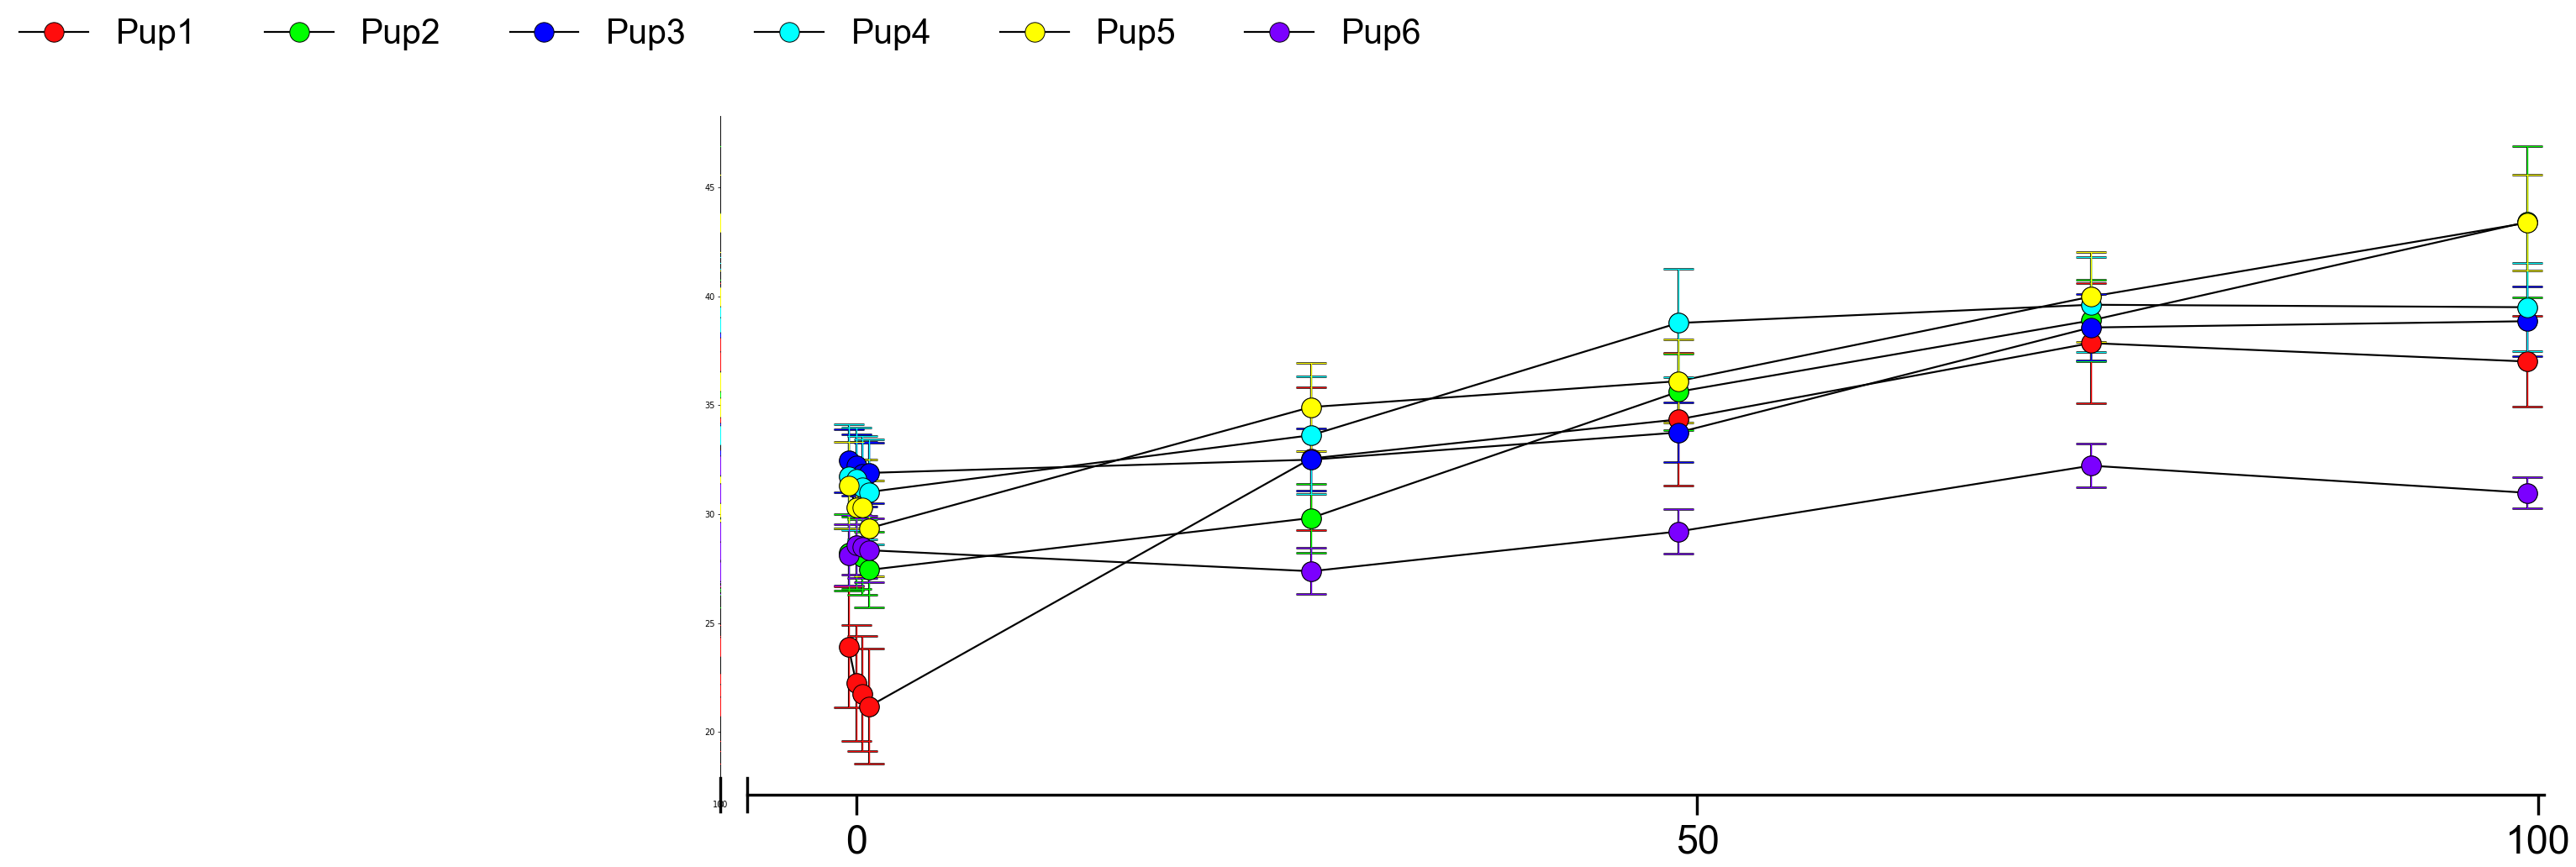

In [27]:
# # Plot post-treatment values with SEM whiskers and a broken (split) x-axis
workbook = xl.load_workbook(excelName)
prs = Presentation()
blank_slide_layout = prs.slide_layouts[6]
r=0
with plt.ion():
    for name, mean_metr in tqdm_notebook(parameters.items(), total=((len(parameters.keys()))) , desc='Plotting and saving graphs on ' + str(time.ctime(time.time()))):
        if post_on.size == 0:
            fig1, axs1 = plt.subplots(1, 1, figsize=(40, 15), gridspec_kw=dict(hspace=0, wspace=0), sharex='none', sharey=True)
            axs1.patch.set_alpha(0.0)
            realistic_x = []
            for trt, row in mean_metr.items():
                if name[0] != 'n':
                    x = [df[name].index.get_loc(ind) for ind in after]
                elif name[0] == 'n' and any('pretreatment' in ind.lower() for ind in after):
                    x = [df[name].index.get_loc(ind) for ind in after if 'bl' not in ind.lower()]
                realistic_x = [list(realistic_x_axis.values())[i] for i in x]
                axs1.errorbar(realistic_x, np.nan_to_num(np.array(row)[x], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x], copy=False),
                              label=trt, elinewidth=1.4, linewidth=2.25, color='black', marker='o', markersize='24', zorder=3,
                              barsabove=False, capthick=2, markeredgecolor='black',
                              markerfacecolor=res[trt], fmt = ' ', capsize=18, ecolor=res[trt])
                axs1.errorbar(realistic_x, np.nan_to_num(np.array(row)[x], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x], copy=False), label=trt,
                              elinewidth=2.2, linewidth=2.25, color='black', marker='o', markersize='24', zorder=2,
                              barsabove=False, capthick=2.8, markeredgecolor='black',
                              markerfacecolor=res[trt], capsize=18.5, ecolor='black')
                handles, labels = axs1.get_legend_handles_labels()
                handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]
                by_label = dict(zip(labels, handles))
                axs1.legend(by_label.values(), by_label.keys(), ncol=len(res), labelspacing=1, columnspacing=2,
                            bbox_to_anchor=(0.20, 1.05), loc="lower left", framealpha=0, prop=legends_on)
        else:
            custom_fig_size=(40, 15)
            fig1, (axs1,axs2) = plt.subplots(1, 2, figsize=custom_fig_size, gridspec_kw=dict({'width_ratios': [len(overnight), len(post_on)]}, hspace=0, wspace=0.03),
                                             sharex='none', sharey=True, facecolor='w')
            axs1.patch.set_alpha(0.0)
            axs2.patch.set_alpha(0.0)
            realistic_x = []
            for trt, row in mean_metr.items():
                if name[0] != 'n':
                    x = [df[name].index.get_loc(ind) for ind in after]
                elif name[0] == 'n' and any('pretreatment' in ind.lower() for ind in after):
                    x = [df[name].index.get_loc(ind) for ind in after if 'bl' not in ind.lower()]
                x2 = [df[name].index.get_loc(ind) for ind in post_on]
                realistic_x = [list(realistic_x_axis.values())[i] for i in x]
                realistic_x2 = [list(realistic_x_axis.values())[i] for i in x2]
                axs1.errorbar(realistic_x, np.nan_to_num(np.array(row)[x], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x], copy=False),
                              label=trt, elinewidth=1.4, linewidth=2.25, color='black', marker='o', markersize='24', zorder=3,
                              barsabove=False, markeredgecolor='black', markerfacecolor=res[trt], fmt = ' ',
                              capsize=18.4, capthick=1.2, ecolor=res[trt])
                axs1.errorbar(realistic_x, np.nan_to_num(np.array(row)[x], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x], copy=False),
                              label=trt, elinewidth=2.2, linewidth=2.25, color='black', marker='o', markersize='24', zorder=2,
                              barsabove=False, markeredgecolor='black', markerfacecolor=res[trt],
                              capsize=18.8, capthick=2.6, ecolor='black')
                axs2.errorbar(realistic_x2, np.nan_to_num(np.array(row)[x2], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x2], copy=False),
                              label=trt, elinewidth=1.4, linewidth=2.25, color='black', marker='o', markersize='24', zorder=3,
                              barsabove=False, markeredgecolor='black', markerfacecolor=res[trt], fmt = ' ',
                              capsize=18.4, capthick=1.2, ecolor=res[trt])
                axs2.errorbar(realistic_x2, np.nan_to_num(np.array(row)[x2], copy=False),
                              yerr = np.nan_to_num(np.array(sem[name][trt])[x2], copy=False),
                              label=trt, elinewidth=2.2, linewidth=2.25, color='black', marker='o', markersize='24', zorder=2,
                              barsabove=False, markeredgecolor='black', markerfacecolor=res[trt],
                              capsize=18.8, capthick=2.6, ecolor='black')
            
            axs2.set_xlim(realistic_x_axis[post_on[0]]-6, realistic_x_axis[post_on[-1]] + 1)
            plt.setp(axs2, xticks=np.arange(round(realistic_x_axis[post_on[0]]), round(realistic_x_axis[post_on[-1]] + 50), 50))
            axs2.tick_params(axis='x', length=25, width=3.5, pad=12)
            plt.setp(axs2.xaxis.get_majorticklabels(), rotation=0, fontproperties=titles_and_axes_on)
            axs2.spines['left'].set_visible(False)
            axs2.spines['bottom'].set_linewidth(3.5)
            axs2.spines['top'].set_visible(False)
            axs2.spines['right'].set_visible(False)
            axs2.yaxis.set_visible(False)
            axs2.grid(False)
            d = .025 # how big to make the diagonal lines in axes coordinates
            kwargs = dict(transform=axs1.transAxes, color='k', clip_on=False, linewidth=3.5)
            axs1.plot((1,1), (-d,+d), **kwargs)
            kwargs.update(transform=axs2.transAxes)
            axs2.plot((0,0), (-d,+d), **kwargs)
            handles, labels = axs1.get_legend_handles_labels()
            handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]
            by_label = dict(zip(labels, handles))
            axs1.legend(by_label.values(), by_label.keys(), ncol=len(res), labelspacing=1, columnspacing=2,
                        bbox_to_anchor=(0.6, 1.05), loc="lower center", framealpha=0, prop=legends_on)

        # Settings common to both cases
        axs1.set_xlim(realistic_x_axis[overnight[0]]-0.5, realistic_x_axis[overnight[-1]]+0.5)
        plt.setp(axs1, xticks=np.arange(0, round(realistic_x_axis[overnight[-1]]+1.51), 1))
        plt.setp(axs1.yaxis.get_majorticklabels(), fontproperties=titles_and_axes_on)
        plt.setp(axs1.xaxis.get_majorticklabels(), rotation=0, fontproperties=titles_and_axes_on)
        axs1.tick_params(axis='both', labelright='off', length=25, width=3.5, pad=12)
        axs1.spines['left'].set_linewidth(3.5)
        axs1.spines['bottom'].set_linewidth(3.5)
        axs1.spines['top'].set_visible(False)
        axs1.spines['right'].set_visible(False)
        axs1.yaxis.tick_left()
        axs1.grid(False)
        oldname = name
        if name[0] == 'n':
            name = re.sub('^n', 'Normalized ', name) # use '^n' to replace the first lowercase n by 'Normalized',there is no length limit unlike for excel sheet names
            name = re.sub(r' \([^()]*\)', '', name) # use ' (*' as a marker to delete units (all units in names are inside parentheses)
        fig1.text(0.5, -0.02, 'Time (hours)', ha='center', fontproperties=titles_and_axes_on)
        axs1.set_ylabel(name, labelpad=35, fontproperties=titles_and_axes_on)
        # Set bottom ylimit to 0 if ylim[0] > 0
        ymin, ymax = axs1.get_ylim()
        if ymin > 0:
            axs1.set_ylim(ymin=0, ymax=ymax*1.1)
        else:
            pass
        axs1.annotate('', xy=(realistic_x_axis[[k for k in realistic_x_axis.keys() if 'ac' in k][0]], axs1.get_ylim()[0]),
                      xytext=(realistic_x_axis[[k for k in realistic_x_axis.keys() if 'ac' in k][0]], axs1.get_ylim()[1]), rotation=0,
                      ha='center', va='center', annotation_clip=False, zorder=1,
                      arrowprops={"color" : "black", "arrowstyle" : "-", "linestyle" : ":", "linewidth" : 2, "shrinkA": 0, "shrinkB": 0})

        axs1.text(realistic_x_axis[[k for k in realistic_x_axis.keys() if 'ac' in k][0]]+0.15, axs1.get_ylim()[1]*0.89,
                  'DIV'+str(day_of_treatment), rotation=90, fontname='Arial', color='black', fontsize=40, ha='left', va='baseline') # if text separates more than 0.2 from the line is because of autoshrink
        if post_on.size > 0:
            axs2.annotate('', xy=(realistic_x_axis[post_on[0]], axs2.get_ylim()[0]),
                          xytext=(realistic_x_axis[post_on[0]], axs2.get_ylim()[1]), rotation=0,
                          fontsize=37, fontname='Arial', color='black', ha='center', va='center', annotation_clip=False, zorder=1,
                          arrowprops={"color" : "black", "arrowstyle" : "-", "linestyle" : ":", "linewidth" : 2, "shrinkA": 0, "shrinkB": 0})

            axs2.text(realistic_x_axis[post_on[0]]+0.3, axs1.get_ylim()[1]*0.89,
                      post_on[0].upper(), rotation=90, fontname='Arial', color='black', fontsize=40, ha='left', va='baseline')
            axs2.annotate('', xy=(realistic_x_axis[post_on[-1]], axs2.get_ylim()[0]),
                          xytext=(realistic_x_axis[post_on[-1]], axs2.get_ylim()[1]), rotation=0,
                          fontsize=37, fontname='Arial', color='black', ha='center', va='center', annotation_clip=False, zorder=1,
                          arrowprops={"color" : "black", "arrowstyle" : "-", "linestyle" : ":", "linewidth" : 2, "shrinkA": 0, "shrinkB": 0})

            axs2.text(realistic_x_axis[post_on[-1]]+0.3, axs1.get_ylim()[1]*0.89,
                      post_on[-1].upper(), rotation=90, fontname='Arial', color='black', fontsize=40, ha='left', va='baseline')

        # Save the figures as .png to folder within the loop
        if os.path.isdir(os.path.join(output_dir,'Graphs per electrode')) == False:
            os.mkdir(os.path.join(output_dir,'Graphs per electrode'))
        fig1.savefig(os.path.join(output_dir,'Graphs per electrode\\') + name, edgecolor='none', transparent=False)
        
        # Insert figures on the fly on their corresponding worksheet
        sheet = workbook[oldname]
        img = xl.drawing.image.Image(os.path.join(output_dir,'Graphs per electrode\\') + name + '.png')
        img.width = 23*custom_fig_size[0]
        img.height = 30*custom_fig_size[1]
        sheet.add_image(img, '{}{}'.format('A', len(cleandatesdict.keys())+4))
        
        # Save figures to a .pptx within the loop
        left=Inches(2.9)
        top=Inches(0.05)
        width=Inches(6.75)
        img_path = os.path.join(output_dir,'Graphs per electrode\\') + name + '.png'
        if r == 0:
            slide = prs.slides.add_slide(blank_slide_layout)
            pic = slide.shapes.add_picture(img_path, left, top, width)
            txBox = slide.shapes.add_textbox(Inches(0.1), Inches(0.1), Inches(3), Inches(0.5))
            tf = txBox.text_frame
            tf.text = name
            tf.paragraphs[0].font.bold = True
            tf.paragraphs[0].font.size = Pt(20)
            r=1
        elif r==1:
            top=Inches(3.75)
            pic = slide.shapes.add_picture(img_path, left, top, width)
            r=0
        
#         plt.show(close=None, block=None) # Inline plotting consumes many resources and hugely increases running time
#         prs.save('Presentation.pptx') # Save after each iteration so I can see the live evolution of the file

plt.close('all') # Close all figures and do not display any inline after running the loop (inline plotting is time-consuming)
prs.save(os.path.join(output_dir,'Graphs per electrode.pptx')) # Save pptx after the loop is done to save time
workbook.save(excelName)

# Move all .csv files to "analysis files" folder
# if os.path.isdir('Unsorted analysis files') == False:
#     os.mkdir('Unsorted analysis files')
# for fl in input_files:
#     if '.csv' in fl or '.txt' in fl:
#         shutil.move(fl, os.path.join('Unsorted analysis files', fl))